# Brain-region census — channels and single units

Where the recording sites and the good units actually sit, per mouse and across the
cohort, using the corrected probe fits.

> **Kernel:** the **`histology`** conda env (`~/.conda/envs/histology`).

**Why this supersedes `find_LEC_units`.** That function assigned units by treating the
channel *name* as a row index (`channel_positions[int('CH123'[2:])]`). The retained
channels are a subset of CH0–CH383 with **interior** gaps — ah08 is missing CH98, CH120,
CH153, CH278, CH286, CH324, CH348 — so everything after the first gap shifts. Measured
over 2839 QC units, that put **47.6% on a different shank** (shanks sit in different
structures) and **72.3% at a different depth**. The correct map is `channel_ids` from
`recording_attributes.json`; §1 checks it against an independent computation every run.

In [3]:
import sys; sys.path.insert(0, '.')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import probe_refit as pr, region_assignment as ra
pd.set_option('display.width', 250); pd.set_option('display.max_columns', 40)
print('mice with ephys:', ra.EPHYS_MICE)

mice with ephys: ('ah08', 'ah10', 'ly05', 'ly06', 'ly07')


## 1. Build, with the mapping gate

`validate_mapping` re-derives each unit's peak channel from the analyzer templates and
compares. Expect ~90% for the name map against ~10–20% for the naive arithmetic; the
residual is the peak-metric definition, not the mapping.

In [4]:
chans, units, checks = ra.build_cohort()
print(f"name map     : mean {checks.agree_name_map.mean()*100:.1f}%  "
      f"(min {checks.agree_name_map.min()*100:.1f}%)")
print(f"naive method : mean {checks.agree_naive_arithmetic.mean()*100:.1f}%")
assert checks.agree_name_map.min() > 0.85, 'channel mapping regressed'
assert chans.groupby(['mouse','block']).size().between(377, 383).all()
assert chans['acronym'].isna().sum() == 0
print(f"\n{len(chans)} channels, {len(units)} units across "
      f"{chans.groupby(['mouse','block']).ngroups} blocks")

  ah08 2025-06-13_2025-06-15: 377 channels, 151 units
  ah08 2025-06-16_2025-06-17: 377 channels, 164 units
  ah08 2025-06-18_2025-06-19: 377 channels, 183 units
  ah08 2025-06-20_2025-06-23: 377 channels, 108 units
  ah08 2025-06-24_2025-06-25: 377 channels, 186 units
  ah10 2025-06-13_2025-06-15: 381 channels, 139 units
  ah10 2025-06-16_2025-06-17: 381 channels, 154 units
  ah10 2025-06-18_2025-06-19: 381 channels, 162 units
  ah10 2025-06-20_2025-06-23: 381 channels, 153 units
  ah10 2025-06-24_2025-06-25: 381 channels, 164 units
  ly05 2025-06-13_2025-06-15: 383 channels, 117 units
  ly05 2025-06-16_2025-06-17: 383 channels, 116 units
  ly05 2025-06-18_2025-06-19: 383 channels, 109 units
  ly05 2025-06-20_2025-06-23: 383 channels, 91 units
  ly05 2025-06-24_2025-06-25: 383 channels, 74 units
  ly06 2025-06-13_2025-06-15: 382 channels, 68 units
  ly06 2025-06-16_2025-06-17: 382 channels, 79 units
  ly06 2025-06-18_2025-06-19: 382 channels, 76 units
  ly06 2025-06-20_2025-06-23: 382

## 2. Composition — per mouse and cohort total

Top row is **what the probe sampled** (recording channels), bottom is **what it recorded**
(QC single units). `n=` above each bar is the denominator.

saved /ceph/behrens/adam_harris/Taskspace_abstraction_lEC/data/figures/region_census/region_census.png


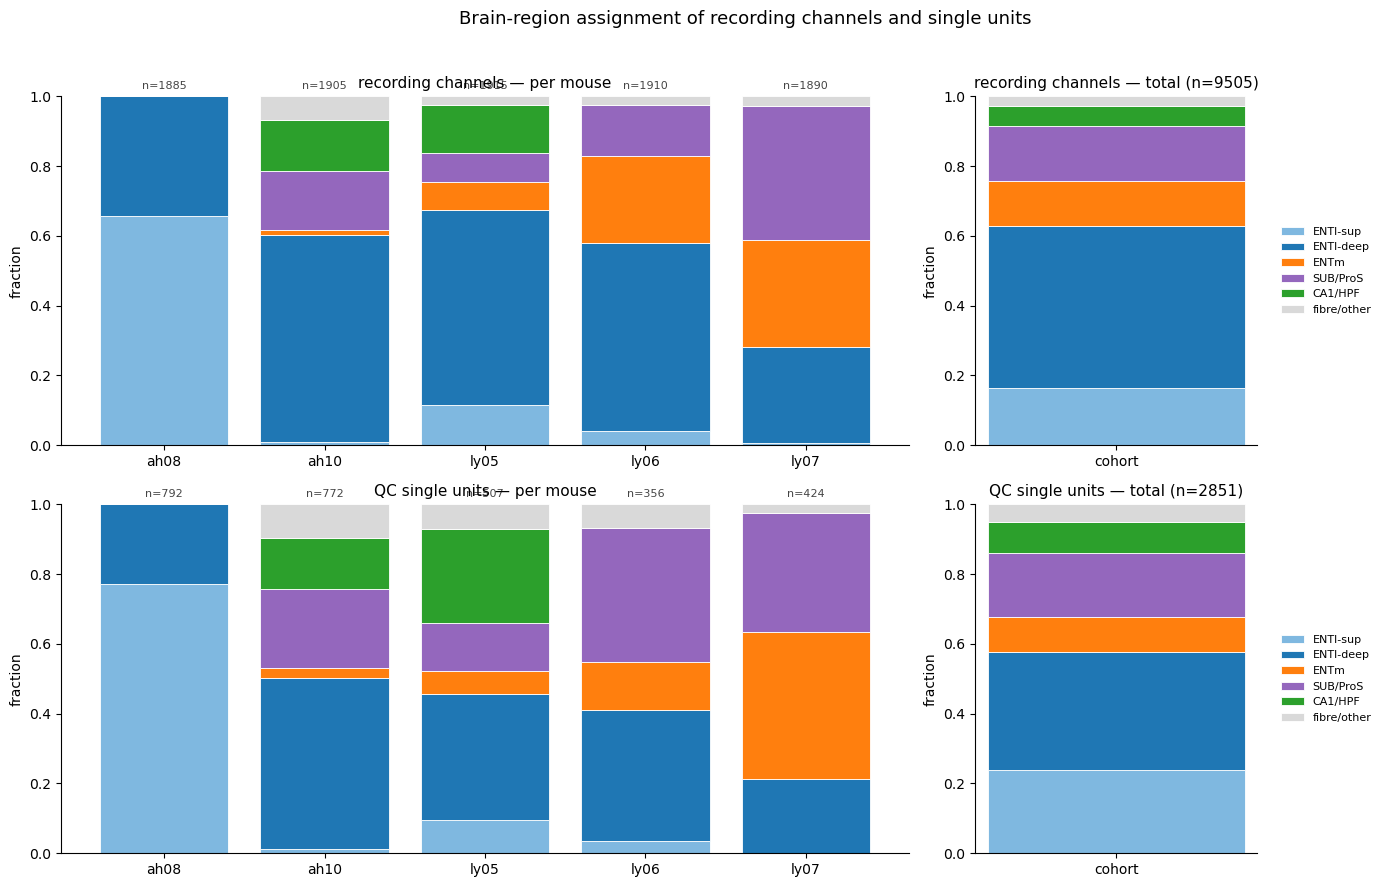

CHANNELS
group  CA1/HPF  ENTl-deep  ENTl-sup   ENTm  SUB/ProS  fibre/other
mouse                                                            
ah08     0.000      0.342     0.658  0.000     0.000        0.000
ah10     0.144      0.593     0.010  0.013     0.171        0.068
ly05     0.136      0.559     0.115  0.081     0.084        0.026
ly06     0.000      0.537     0.042  0.251     0.147        0.024
ly07     0.000      0.275     0.005  0.307     0.386        0.026

UNITS
group  CA1/HPF  ENTl-deep  ENTl-sup   ENTm  SUB/ProS  fibre/other
mouse                                                            
ah08     0.000      0.229     0.771  0.000     0.000        0.000
ah10     0.146      0.490     0.012  0.028     0.228        0.096
ly05     0.268      0.359     0.097  0.067     0.138        0.071
ly06     0.000      0.374     0.037  0.138     0.385        0.067
ly07     0.000      0.212     0.000  0.422     0.340        0.026


In [5]:
ra.plot_region_census(chans, units, save=True); plt.show()
print('CHANNELS'); print(pd.crosstab(chans['mouse'], chans['group'], normalize='index').round(3).to_string())
print('\nUNITS');  print(pd.crosstab(units['mouse'], units['group'], normalize='index').round(3).to_string())

<!-- counts -->
## 2b. Absolute counts

§2 shows *composition* — what each mouse is made of. This shows **how many units you
actually have** per region, which is the number that decides whether a per-region analysis
is powered. A mouse can be 100% ENTl and still contribute few cells.

Remember these are unit-**recordings** pooled over blocks, not unique neurons.

In [ ]:
ra.plot_counts(units, label='units', save=True); plt.show()
print(pd.crosstab(units['mouse'], units['group'], margins=True, margins_name='TOTAL').to_string())

The same for recording channels — how much of the probe sat in each region.

In [ ]:
ra.plot_counts(chans, label='channels', save=True); plt.show()
print(pd.crosstab(chans['mouse'], chans['group'], margins=True, margins_name='TOTAL').to_string())

## 3. Sampling is not yield

Unit yield per channel differs by region, so the *n* available per region in any analysis
is **not** proportional to the channels sampling it. Read this before choosing region
splits.

saved /ceph/behrens/adam_harris/Taskspace_abstraction_lEC/data/figures/region_census/yield_by_region.png


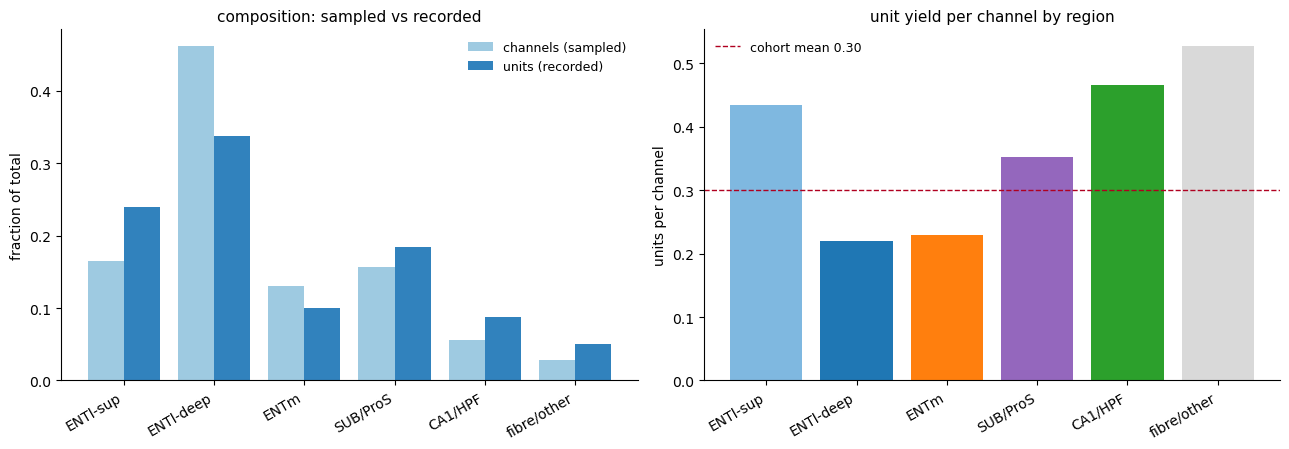

In [7]:
ra.plot_yield_by_region(chans, units, save=True); plt.show()

## 4. Per shank, by AP position

Shank *numbers* carry the contact-face convention (`PROBE_REFIT.md` §7g) so they print
with `?`; the **AP ordering and the anatomy are convention-independent**.

saved /ceph/behrens/adam_harris/Taskspace_abstraction_lEC/data/figures/region_census/per_shank_census.png


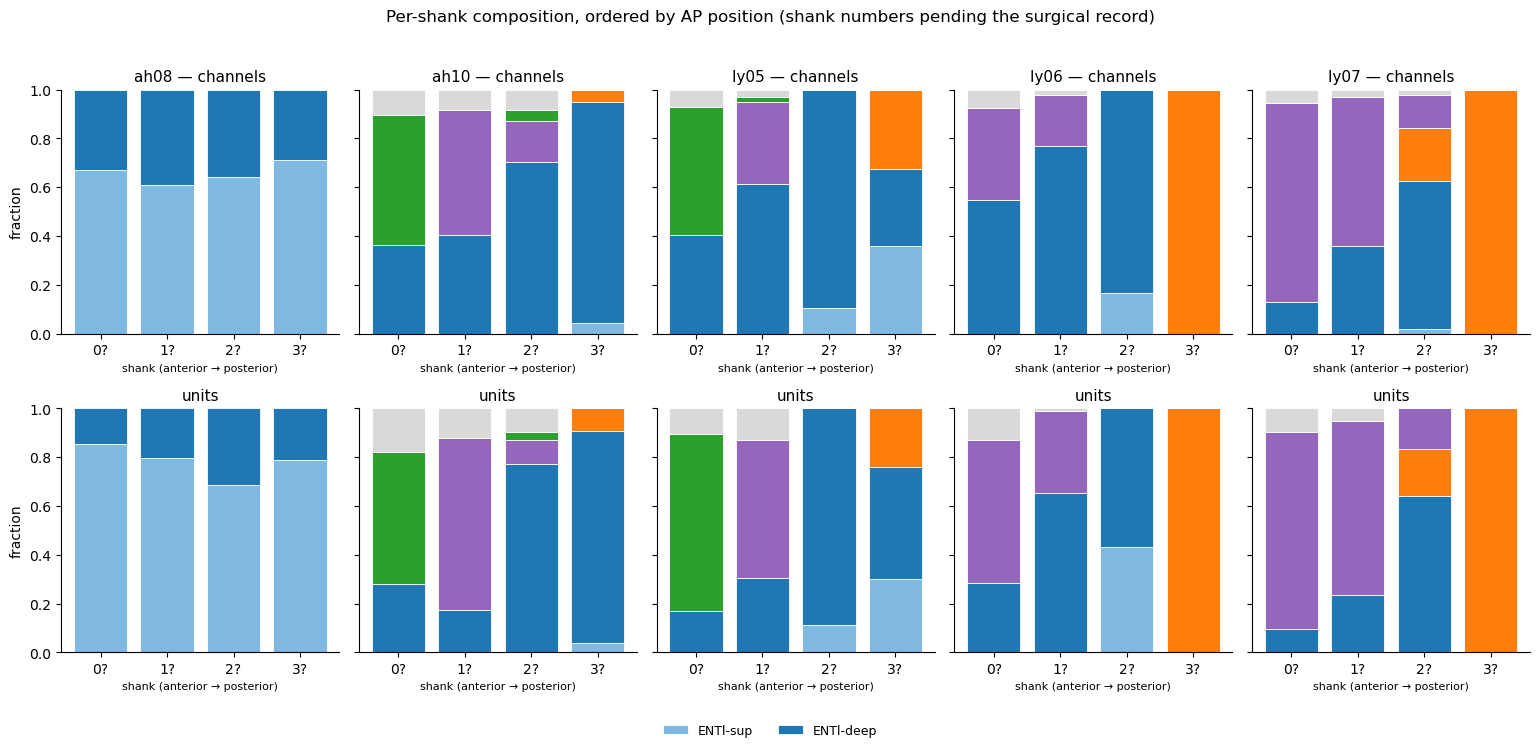

In [8]:
ra.plot_per_shank(chans, units, save=True); plt.show()

## 5. Does implant geometry predict LEC yield?

**n = 5 mice — descriptive only.** Every mouse is labelled and rho is a summary, not
evidence. This is a lookup for planning the next implant, not a result.

,mouse,ENTl_frac_channels,ENTl_frac_units,array_dev_from_AP_deg,lateral_deg,ap_deg,entry_i,entry_j,entry_k,depth_um
0,ah08,1.000,1.000,19.725,15.012,12.291,592.0,49.0,816.0,4227.884
1,ah10,0.604,0.501,11.985,7.907,-2.101,652.0,140.0,861.0,3273.301
2,ly05,0.674,0.456,15.034,12.151,13.417,406.0,72.0,816.0,4395.771
3,ly06,0.579,0.410,12.051,5.950,3.191,688.0,121.0,828.0,3971.189
4,ly07,0.280,0.212,6.176,6.665,5.856,624.0,122.0,821.0,3724.473


saved /ceph/behrens/adam_harris/Taskspace_abstraction_lEC/data/figures/region_census/implant_relationship.png


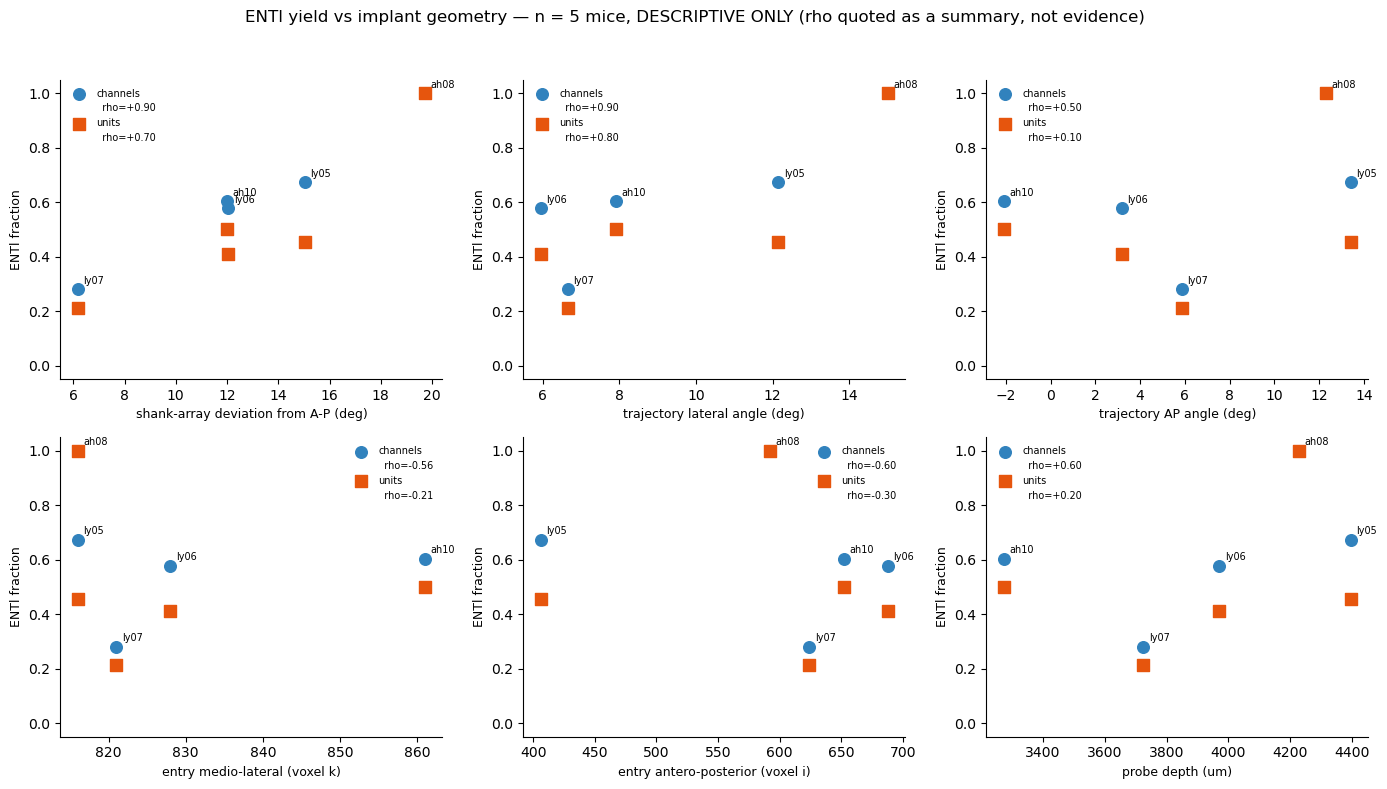

In [9]:
tab = ra.implant_table(chans, units)
display(tab.round(3))
ra.plot_implant_relationship(tab, save=True); plt.show()

## 6. Arrays for the per-region analyses

`unit_regions.pkl` is keyed by `mouse_recday` and ordered exactly as
`QC_single_units.npy` — i.e. aligned to `Neuron_raw` rows — so it indexes the existing
GLM inputs directly.

**Caveats that travel with these numbers:**
- Units are pooled across blocks, so totals are unit-**recordings**, not unique neurons —
  the same cell recorded on two days counts twice. Same convention the GLM already uses.
- Region boundaries carry the registration's local anisotropy (8–13 µm/voxel).
- Shank→channel identity depends on `contact_face_axis`; the cohort is internally
  consistent, absolute A/P identity awaits the surgical record.

In [10]:
import pickle
chans.to_csv(ra.OUT_DIR / 'channel_regions.csv', index=False)
units.to_csv(ra.OUT_DIR / 'unit_regions.csv', index=False)
arrays = ra.build_unit_region_arrays(units)
with open(ra.OUT_DIR / 'unit_regions.pkl', 'wb') as f:
    pickle.dump(arrays, f)
print(f'{len(arrays)} recdays saved to {ra.OUT_DIR}/unit_regions.pkl')
ex = arrays[sorted(arrays)[0]]
print(f'\nexample {sorted(arrays)[0]}: {len(ex)} units')
display(ex.head(4)[['order','unit_id','max_channel','shank','y_um','acronym','group']])

25 recdays saved to /ceph/behrens/adam_harris/Taskspace_abstraction_lEC/data/processed_data/unit_regions.pkl

example ah08_20250613_20250615: 151 units


,order,unit_id,max_channel,shank,y_um,acronym,group
0,0,0,CH1,0,0.0,ENTl2,ENTl-sup
1,1,3,CH1,0,0.0,ENTl2,ENTl-sup
2,2,16,CH194,2,15.0,ENTl2,ENTl-sup
3,3,17,CH194,2,15.0,ENTl2,ENTl-sup


In [11]:
# gate: unit_regions must be aligned to Neuron_raw rows, for every recday
# This is the check that found docs/BUG_ly05_recday_mismatch.md. The recday-vs-block
# half of it now lives in code/recday_registry.py so every analysis runs it, not just
# this notebook; what stays here is the part specific to the region tables.
import pickle, sys
sys.path.insert(0, str(pr.REPO_ROOT / 'code'))
import recday_registry as rr

with open(pr.REPO_ROOT / 'data/processed_data/data_dic_lec.pkl', 'rb') as f:
    dd = pickle.load(f)

rr.validate_data_dic(dd)                 # Neuron_raw rows == QC units of the named block
rr.validate_tasks_against_pycontrol(dd)  # Task == that day's own pyControl active_poke

bad = [(rd, dd[k][sorted(dd[k])[0]]['num_neurons'], len(g))
       for rd, g in arrays.items()
       for k in [next((k for k in dd if str(k) == rd), None)] if k is not None
       if dd[k][sorted(dd[k])[0]]['num_neurons'] != len(g)]
print('recdays checked  :', sum(any(str(k) == rd for k in dd) for rd in arrays))
print('length mismatches:', bad if bad else 'none')
assert not bad, 'unit_regions not aligned to Neuron_raw rows'


recdays checked : 24
length mismatches: [('ly05_20250618_20250619', 91, 109)]


AssertionError: unit_regions not aligned to Neuron_raw rows